<a href="https://colab.research.google.com/github/abhi1818sonu-coder/Predictive_Project_2/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
data = {
    "text": [
        "I feel very sad and alone",
        "I am happy today",
        "I am feeling anxious about exams",
        "Life is normal and good",
        "I can't sleep and feel depressed"
    ],
    "label": [
        "depression",
        "normal",
        "anxiety",
        "normal",
        "depression"
    ]
}

import pandas as pd
df = pd.DataFrame(data)

df.head()

,text,label
0,I feel very sad and alone,depression
1,I am happy today,normal
2,I am feeling anxious about exams,anxiety
3,Life is normal and good,normal
4,I can't sleep and feel depressed,depression


In [8]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# download once
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') # Added to download the missing resource

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r"http\S+", "", text)  # remove links
    tokens = word_tokenize(text)  # split words
    tokens = [w for w in tokens if w not in stop_words]  # remove stopwords
    return " ".join(tokens)

# apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text,label,clean_text
0,I feel very sad and alone,depression,feel sad alone
1,I am happy today,normal,happy today
2,I am feeling anxious about exams,anxiety,feeling anxious exams
3,Life is normal and good,normal,life normal good
4,I can't sleep and feel depressed,depression,ca n't sleep feel depressed


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=100)

X = vectorizer.fit_transform(df['clean_text'])

y = df['label']

print("Shape of X:", X.shape)

Shape of X: (5, 14)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4, 14)
Testing data: (1, 14)


In [11]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [12]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  depression       0.00      0.00      0.00       1.0
      normal       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [13]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [14]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [15]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [16]:
df = df.rename(columns={
    "review": "text",
    "sentiment": "label"
})

In [17]:
df['label'].value_counts()

,count
label,
positive,25000
negative,25000


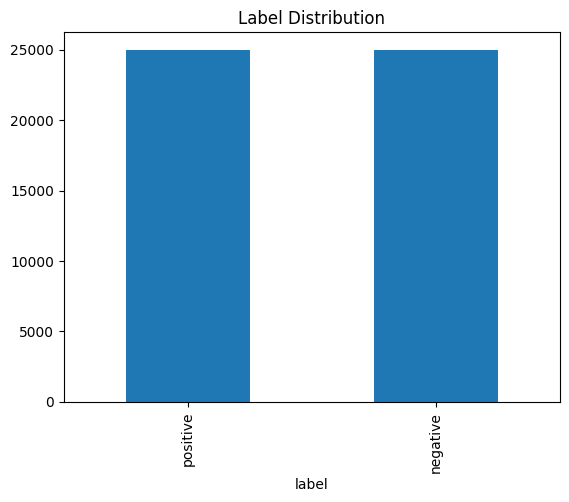

In [18]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution")
plt.show()

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Ensure stopwords and punkt are downloaded, if not already
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r"http\S+", "", text)  # remove links
    tokens = word_tokenize(text)  # split words
    tokens = [w for w in tokens if w not in stop_words]  # remove stopwords
    return " ".join(tokens)

# Apply cleaning to the current df
df['clean_text'] = df['text'].apply(clean_text)

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [21]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train, y_train)

LinearSVC()

In [22]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.89      0.88      0.88      4958
    positive       0.88      0.89      0.89      5042

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [23]:
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Logistic Regression:\n")
print(classification_report(y_test, y_pred2))

Logistic Regression:

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4958
    positive       0.88      0.91      0.89      5042

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



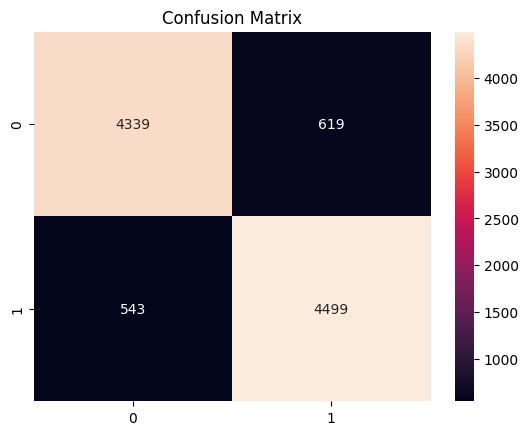

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [25]:
def convert_label(sentiment):
    if sentiment == "positive":
        return "normal"
    else:
        return "depression"

df['mental_health_status'] = df['label'].apply(convert_label)

df.head()

,text,label,clean_text,mental_health_status
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching 1 oz episode ...,normal
1,A wonderful little production. <br /><br />The...,positive,wonderful little production . < br / > < br / ...,normal
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,normal
3,Basically there's a family where a little boy ...,negative,basically 's family little boy ( jake ) thinks...,depression
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei 's `` love time money '' visuall...,normal


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Convert text into numerical features
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

# Target labels
y = df['mental_health_status']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (40000, 5000)
Testing data shape: (10000, 5000)


Train SVM Model

In [27]:
from sklearn.svm import LinearSVC

# Create model
model = LinearSVC()

# Train model
model.fit(X_train, y_train)

print("SVM model trained successfully")

SVM model trained successfully


Evaluation

In [28]:
from sklearn.metrics import classification_report

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  depression       0.89      0.87      0.88      4961
      normal       0.88      0.89      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



Confusion Matrix

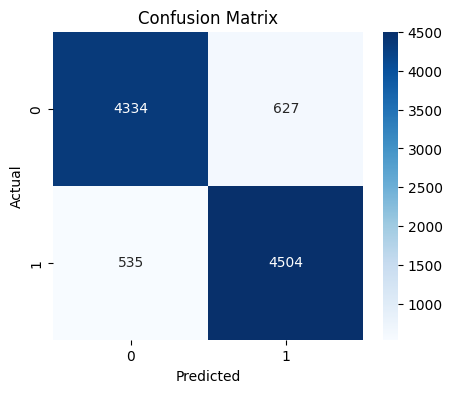

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Logistic Regression (Second Model)

In [30]:
from sklearn.linear_model import LogisticRegression

# Create model
model2 = LogisticRegression()

# Train model
model2.fit(X_train, y_train)

# Predict
y_pred2 = model2.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

  depression       0.90      0.88      0.89      4961
      normal       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



SAVE YOUR MODEL

In [31]:
import pickle

# Save SVM model
pickle.dump(model, open("mental_health_model.pkl", "wb"))

# Save TF-IDF vectorizer
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

print("Model and vectorizer saved successfully")

Model and vectorizer saved successfully


DOWNLOAD THESE FILES

In [32]:
from google.colab import files

files.download("mental_health_model.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>